In [46]:
import numpy

import AILibs    

dt = 1.0/1000.0 
    

a = numpy.zeros((2, 2))
b = numpy.zeros((2, 1))

a[0][1] = 1
a[1][1] = -4

b[1][0] = 5.0

c = numpy.zeros((1, 2))
c[0][0] = 1
 
ds = AILibs.DynamicalSystem(a, b, c, dt)

print(ds)





mat_a = 
0.0 1.0 
0.0 -4.0 


mat_b = 
0.0 
5.0 


mat_c = 
1.0 0.0 





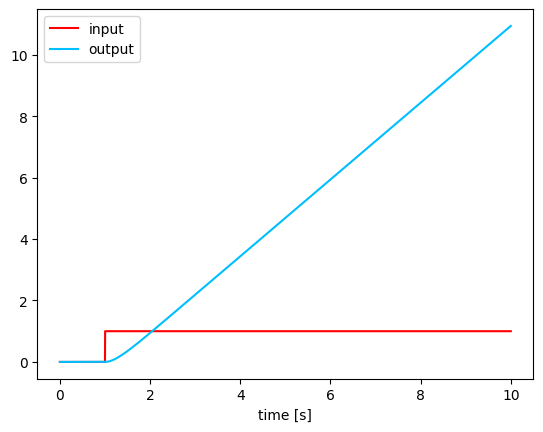

In [47]:
n_steps = 10000

t_result = []
u_result = []
x_result = []

ds.reset()
u = 1
for n in range(n_steps):

    u_tmp = numpy.ones((1, 1))

    if n > n_steps//10:
        u = 1.0
    else:
        u = 0.0

    x, y = ds.forward_state(u_tmp*u)

    t_result.append(n*dt)
    u_result.append(u) 
    x_result.append(x[0][0])


t_result = numpy.array(t_result)
u_result = numpy.array(u_result)
x_result = numpy.array(x_result)


import matplotlib.pyplot as plt

plt.plot(t_result, u_result, label="input", color="red")
plt.plot(t_result, x_result, label="output", color="deepskyblue")
plt.xlabel("time [s]")
plt.legend()
plt.show()


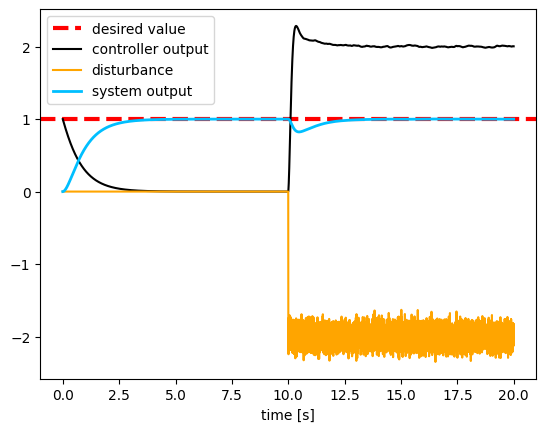

In [48]:
A, B, _ = AILibs.c2d(ds.a, ds.b, ds.c, dt)

Q = numpy.diag([1.0, 0.0])
R = numpy.diag([1.0])

Qo = numpy.diag([1.0, 0.0, 0.01])
Ro = numpy.diag([1.0, 10.0]) 


adrc = AILibs.LQRDO(A, B, Q, R, Qo, Ro)

n_steps = 20000      


xr = numpy.zeros((2, 1))
x  = numpy.zeros((2, 1))  


 
t_result    = []
u_result    = []
d_result    = []
xr_result   = []
x_result    = []

ds.reset()  
adrc.reset()    

for n in range(n_steps):

    xr[0][0] = 1.0
    
    u = adrc.forward(xr, x)

    if n > n_steps//2:
        d = -2 + numpy.random.randn()*0.1
    else:
        d = 0

    x, y = ds.forward_state((u + d))


    t_result.append(n*dt)
    u_result.append(u[0][0]) 
    d_result.append(d) 
    xr_result.append(xr[0][0])
    x_result.append(x[0][0])


t_result    = numpy.array(t_result)
u_result    = numpy.array(u_result)
d_result    = numpy.array(d_result)
xr_result   = numpy.array(xr_result)
x_result    = numpy.array(x_result)


import matplotlib.pyplot as plt

plt.axhline(y=xr[0][0], color='red', linestyle='--', label='desired value', lw=3)
plt.plot(t_result, u_result, label="controller output", color="black")
plt.plot(t_result, d_result, label="disturbance", color="orange")
plt.plot(t_result, x_result, label="system output", color="deepskyblue", lw=2)
plt.xlabel("time [s]")
plt.legend()
plt.show()  
